<h1> Radiation Model Research </h1>

**Testing Linear No-Threshold Model for Radiation Level using Machine Learning and Neural Network**

*What is Linear No-Threshold (LNT) model*

Linear No Threshold is the globaly accepted model to determine safe amount of radiation that any individual can be exposed to in radiation related fields. As stated in its name the model sets no threshold for safe radiation exposer. This was formulated after the Life Span Study (LSS) of the atomic bomb survivors in Hiroshima and Nagasaki. The lack of a threshold is due to the belief that any dose of ionizing radiation, no matter how small, carries a risk of cancer. This led to ALARA (As Low As Reasonably Achievable) as our aim with radiation exposure.

*Life Span Study (LSS)* 

After the atomic bomb explosion in Japan, LSS was started to study the affeces radiation had on survivors. This study later became the basis of our nuclear safety standard as it is the backbone behind LNT. Using LSS as a basis for radiation exposer comes with its probelms, dose-rate being the biggest one. Nuclear explosion is a acute exposer event (high exposer in short period of time) using this data to extrapolate risk for chronic exposer (low exposer over extended period of time) is biologically incompatable. But this was and remains the gold standard for radiation study due to its massive statistical number (120,000 + individuals), demographic diversity, complete dose spectrum and its long term - high quality follow up, hence LSS will also remain as the backbone for our ML model.

<h2>Code</h2>

In [15]:
import pandas as pd
import os
import seaborn as sns
import numpy as np
from pathlib import Path
import time
import openpyxl
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.stats import linregress
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

In [2]:
#import LSS as df
df = pd.read_csv("lss14.csv")

#preparing folder for charts
output_folder = "all charts"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created folder: {output_folder}")
else: 
    print(f"Folder {output_folder} exists")

Folder all charts exists


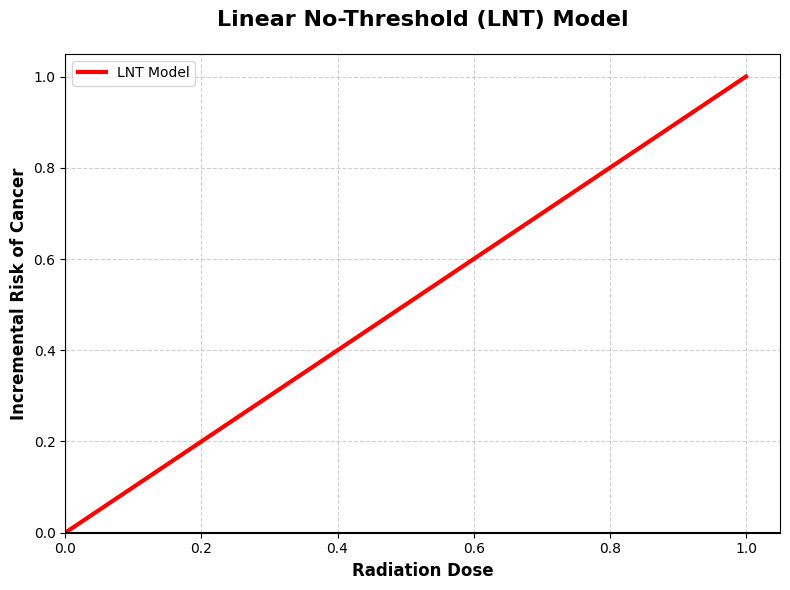

In [ ]:
def plot_simple_lnt():
    dose = np.linspace(0, 1, 100)
    
    risk = dose 
    
    # Create the plot
    plt.figure(figsize=(8, 6))
    
    # Plot the LNT line
    plt.plot(dose, risk, color='red', linewidth=3, label='LNT Model')
    
    # Formatting to match textbook LNT charts
    plt.title('Linear No-Threshold (LNT) Model', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Radiation Dose', fontsize=12, fontweight='semibold')
    plt.ylabel('Incremental Risk of Cancer', fontsize=12, fontweight='semibold')
    
    # Force axes to start exactly at the origin (0,0)
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    
    # Add a bold baseline at x=0 and y=0
    plt.axvline(0, color='black', linewidth=1.5)
    plt.axhline(0, color='black', linewidth=1.5)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_simple_lnt()

In [4]:
def calculate_err(file_path):
    df = pd.read_csv('lss14.csv')

    # 1. "colon10" is taken as the dose variable (standard in radiation study) and is converted from mSv to Sv.
    df['dose_sv'] = df['colon10'] / 1000.0

    # We filter out rows with 0 person-years (pyr) to avoid division errors
    df_clean = df[df['pyr'] > 0].copy()

    # 3. Define the Poisson Regression Model
    # The model predicts 'solid' cancer deaths based on dose,
    # while controlling for background factors (Sex, Age, City).
    # The 'offset' is log(pyr) because we are modeling Rate = Deaths / PYR.
    # Formula: log(Rate) = Intercept + Beta * Dose + Beta_Sex * Sex ...
    
    formula = "solid ~ dose_sv + C(sex) + C(agecat) + C(city)"
    
    model = smf.glm(
        formula=formula, 
        data=df_clean, 
        offset=np.log(df_clean['pyr']), 
        family=sm.families.Poisson()
    )

    # 4. Run the Calculations
    result = model.fit()

    # 5. Extract the Risk Coefficient (Beta)
    # The coefficient 'beta' represents the slope of the log-risk.
    beta = result.params['dose_sv']
    
    # Calculate ERR at 1 Sv
    # Since the model is log-linear: Relative Risk (RR) = exp(beta * dose)
    # ERR = RR - 1
    err_at_1sv = np.exp(beta * 1.0) - 1

    # 6. Output the Results
    print(f"Regression Coefficient (Beta): {beta:.4f}")
    print(f"Excess Relative Risk (ERR) at 1 Sv: {err_at_1sv:.4f} ({err_at_1sv*100:.2f}%)")
    print("Globally Accepeted Value for ERR")

if __name__ == "__main__":
    # Ensure the file 'lss14.csv' is in the same folder
    calculate_err('lss14.csv')

Regression Coefficient (Beta): 0.3513
Excess Relative Risk (ERR) at 1 Sv: 0.4209 (42.09%)
Globally Accepeted Value for ERR


*Analyzing LSS data*

In [5]:
df['dose_gy'] = df['colon10']

# Common definitions for "Low Dose" boundaries
thresholds = [20, 50, 80, 100]

print("--- Ratio by Person-Years (Statistical Weight) ---")
print(f"{'Threshold (mSv)'} {'Low Dose (mSv)'} {'High Dose (mSv)'} {'Ratio (High/Low)'} {'% Data is Low Dose'}")
print("-" * 90)

for thresh in thresholds:
    low_mask = df['dose_gy'] <= thresh
    high_mask = df['dose_gy'] > thresh
    
    # Calculate sums
    low_pyr = df.loc[low_mask, 'pyr'].sum()
    high_pyr = df.loc[high_mask, 'pyr'].sum()
    
    # Calculate ratio
    ratio = high_pyr / low_pyr if low_pyr > 0 else 0
    percent_low = (low_pyr / (low_pyr + high_pyr)) * 100
    
    print(f"{thresh:<15.2f} {low_pyr:<15.0f} {high_pyr:<15.0f} {ratio:<20.4f} {percent_low:.1f}%")

--- Ratio by Person-Years (Statistical Weight) ---
Threshold (mSv) Low Dose (mSv) High Dose (mSv) Ratio (High/Low) % Data is Low Dose
------------------------------------------------------------------------------------------
20.00           2022576         1271706         0.6288               61.4%
50.00           2400342         893941          0.3724               72.9%
80.00           2530659         763623          0.3017               76.8%
100.00          2609197         685085          0.2626               79.2%


In [6]:
df = df.replace(-99.0, np.nan)

df['gender'] = df['sex'].map({1: 'Male', 2: 'Female'})

sites = ['stomach', 'colon', 'rectum', 'liver', 'pancre', 'lung', 'breast', 'uterus', 'ovary', 'prostate', 'bladder', 'kidney']

print("Data loaded successfully. Dataset shape:", df.shape)
df.head()

Data loaded successfully. Dataset shape: (53782, 53)


,city,sex,gd3,ahs,agexcat,agecat,ctime,dosecat,subjects,pyr,...,myeloma,blooddis,cvd,respiratory,digestive,genitourinary,inf,external,dose_gy,gender
0,1,1,1,0,1,2,1,1,259.0,594.82683,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.64096,Male
1,1,1,1,0,1,2,1,2,726.0,1701.26762,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.54022,Male
2,1,1,1,0,1,2,1,3,277.0,571.16359,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,29.09278,Male
3,1,1,1,0,1,2,1,4,151.0,335.21561,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,49.07854,Male
4,1,1,1,0,1,2,1,5,109.0,252.33539,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70.32468,Male


Age Distribution

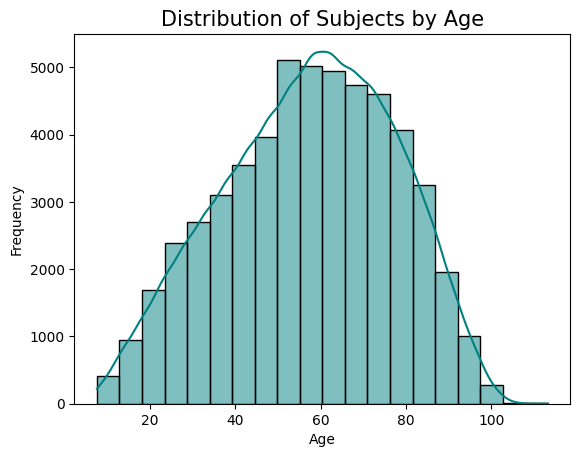

In [7]:
plt.figure()
sns.histplot(df['age'], bins=20, kde=True, color='teal')
plt.title('Distribution of Subjects by Age', fontsize=15)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Mortality by Age

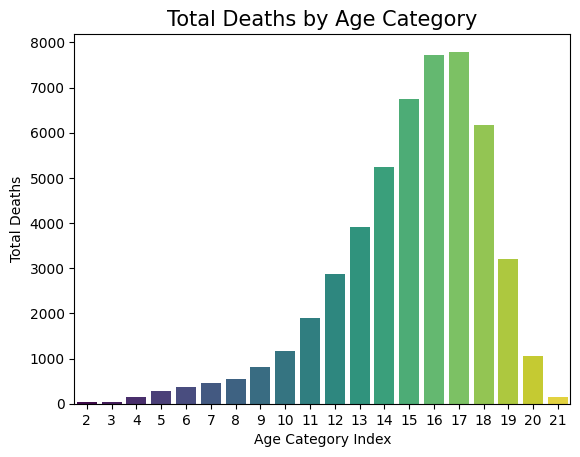

In [8]:
plt.figure()
age_death = df.groupby('agecat')['death'].sum().reset_index()

# Fix: Assign 'agecat' to hue and set legend=False
sns.barplot(
    data=age_death, 
    x='agecat', 
    y='death', 
    hue='agecat', 
    palette='viridis', 
    legend=False
)

plt.title('Total Deaths by Age Category', fontsize=15)
plt.xlabel('Age Category Index')
plt.ylabel('Total Deaths')
plt.show()

Cancer Type

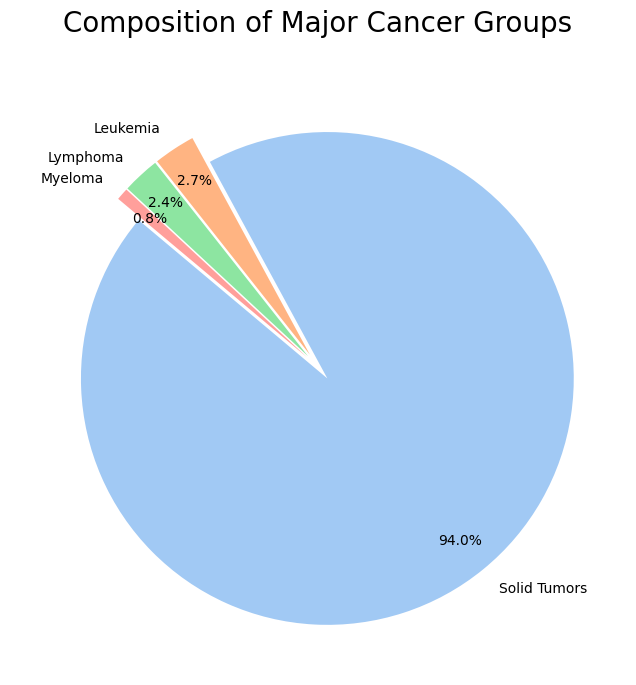

In [9]:
plt.figure(figsize=(11, 8))

cancer_types = {
    'Solid Tumors': df['solid'].sum(),
    'Leukemia': df['leukemia'].sum(),
    'Lymphoma': df['lymphoma'].sum(),
    'Myeloma': df['myeloma'].sum()
}

# Create an explode tuple (e.g., 0.05 for every slice to separate them slightly)
explode = (0.06, 0.06, 0.06, 0.06) 

plt.pie(
    cancer_types.values(), 
    labels=cancer_types.keys(), 
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel'), 
    startangle=140,
    explode=explode,    # Separates the slices
    pctdistance=0.85,    # Moves the % numbers further from the center
    labeldistance=1.1   # Moves the category labels slightly further out
)

plt.title('Composition of Major Cancer Groups', fontsize=20, pad=20)
plt.show()

Does Category vs Mortality Trend

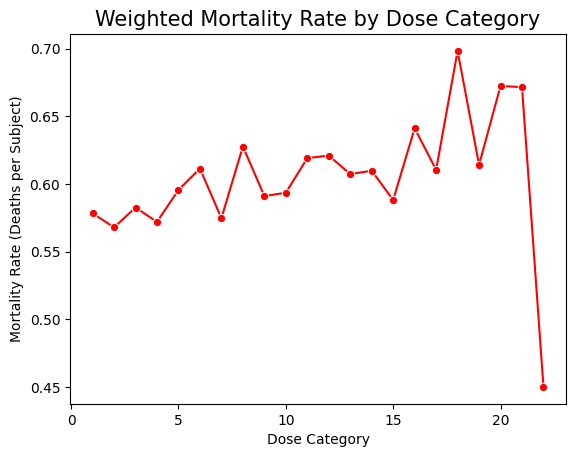

In [10]:
plt.figure()
# Calculate weighted mortality rate (Total deaths / Total subjects) for each dose category
dose_stats = df.groupby('dosecat').agg({'death': 'sum', 'subjects': 'sum'}).reset_index()
dose_stats['mortality_rate'] = dose_stats['death'] / dose_stats['subjects']

sns.lineplot(data=dose_stats, x='dosecat', y='mortality_rate', marker='o', color='red')
plt.title('Weighted Mortality Rate by Dose Category', fontsize=15)
plt.xlabel('Dose Category')
plt.ylabel('Mortality Rate (Deaths per Subject)')
plt.show()

Mortality Counts by Gender

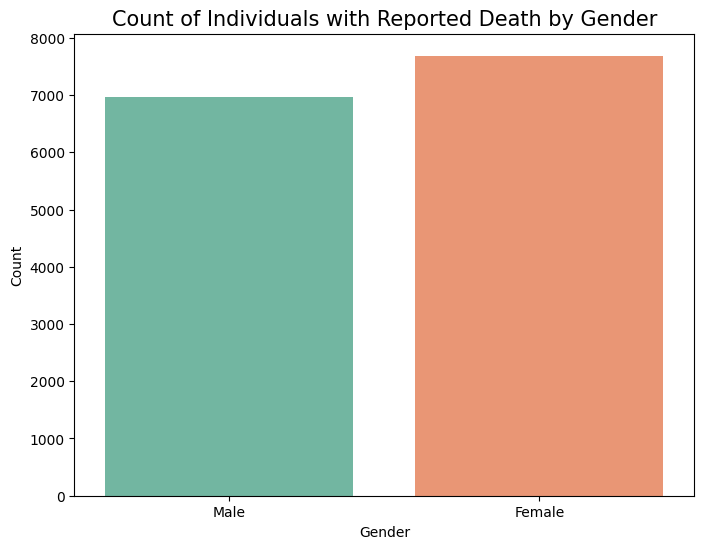

In [11]:
plt.figure(figsize=(8, 6))

# Filter data for reported deaths
death_data = df[df['death'] > 0]

# Fix: Assign 'gender' to hue and set legend=False
sns.countplot(
    data=death_data, 
    x='gender', 
    hue='gender', 
    palette='Set2', 
    legend=False
)

plt.title('Count of Individuals with Reported Death by Gender', fontsize=15)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Age vs Solid Tumors

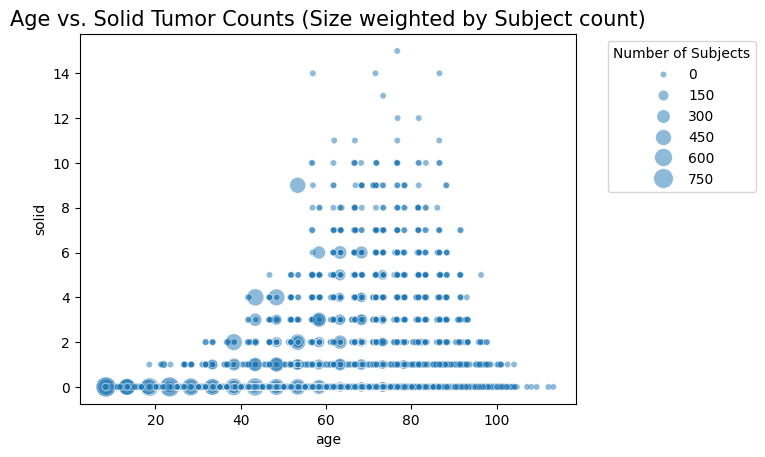

In [12]:
plt.figure()
sns.scatterplot(data=df, x='age', y='solid', alpha=0.5, size='subjects', sizes=(20, 200))
plt.title('Age vs. Solid Tumor Counts (Size weighted by Subject count)', fontsize=15)
plt.legend(title='Number of Subjects', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Doescat grouped survivor vs deaths

Successfully loaded lss14.csv

--- Survival vs Death Rates by Dose Category ---
Dosecat  1: Survived  88.00% | Died 12.00% (Total: 38509)
Dosecat  2: Survived  88.19% | Died 11.81% (Total: 14555)
Dosecat  3: Survived  88.00% | Died 12.00% (Total: 6411)
Dosecat  4: Survived  87.18% | Died 12.82% (Total: 4203)
Dosecat  5: Survived  86.97% | Died 13.03% (Total: 2710)
Dosecat  6: Survived  86.89% | Died 13.11% (Total: 2082)
Dosecat  7: Survived  88.35% | Died 11.65% (Total: 1975)
Dosecat  8: Survived  85.10% | Died 14.90% (Total: 1523)
Dosecat  9: Survived  87.47% | Died 12.53% (Total: 1460)
Dosecat 10: Survived  85.33% | Died 14.67% (Total: 1016)
Dosecat 11: Survived  87.07% | Died 12.93% (Total: 1570)
Dosecat 12: Survived  84.90% | Died 15.10% (Total: 1417)
Dosecat 13: Survived  86.55% | Died 13.45% (Total: 3369)
Dosecat 14: Survived  86.31% | Died 13.69% (Total: 2176)
Dosecat 15: Survived  82.29% | Died 17.71% (Total: 1248)
Dosecat 16: Survived  81.53% | Died 18.47% (Total: 758)
Dosecat

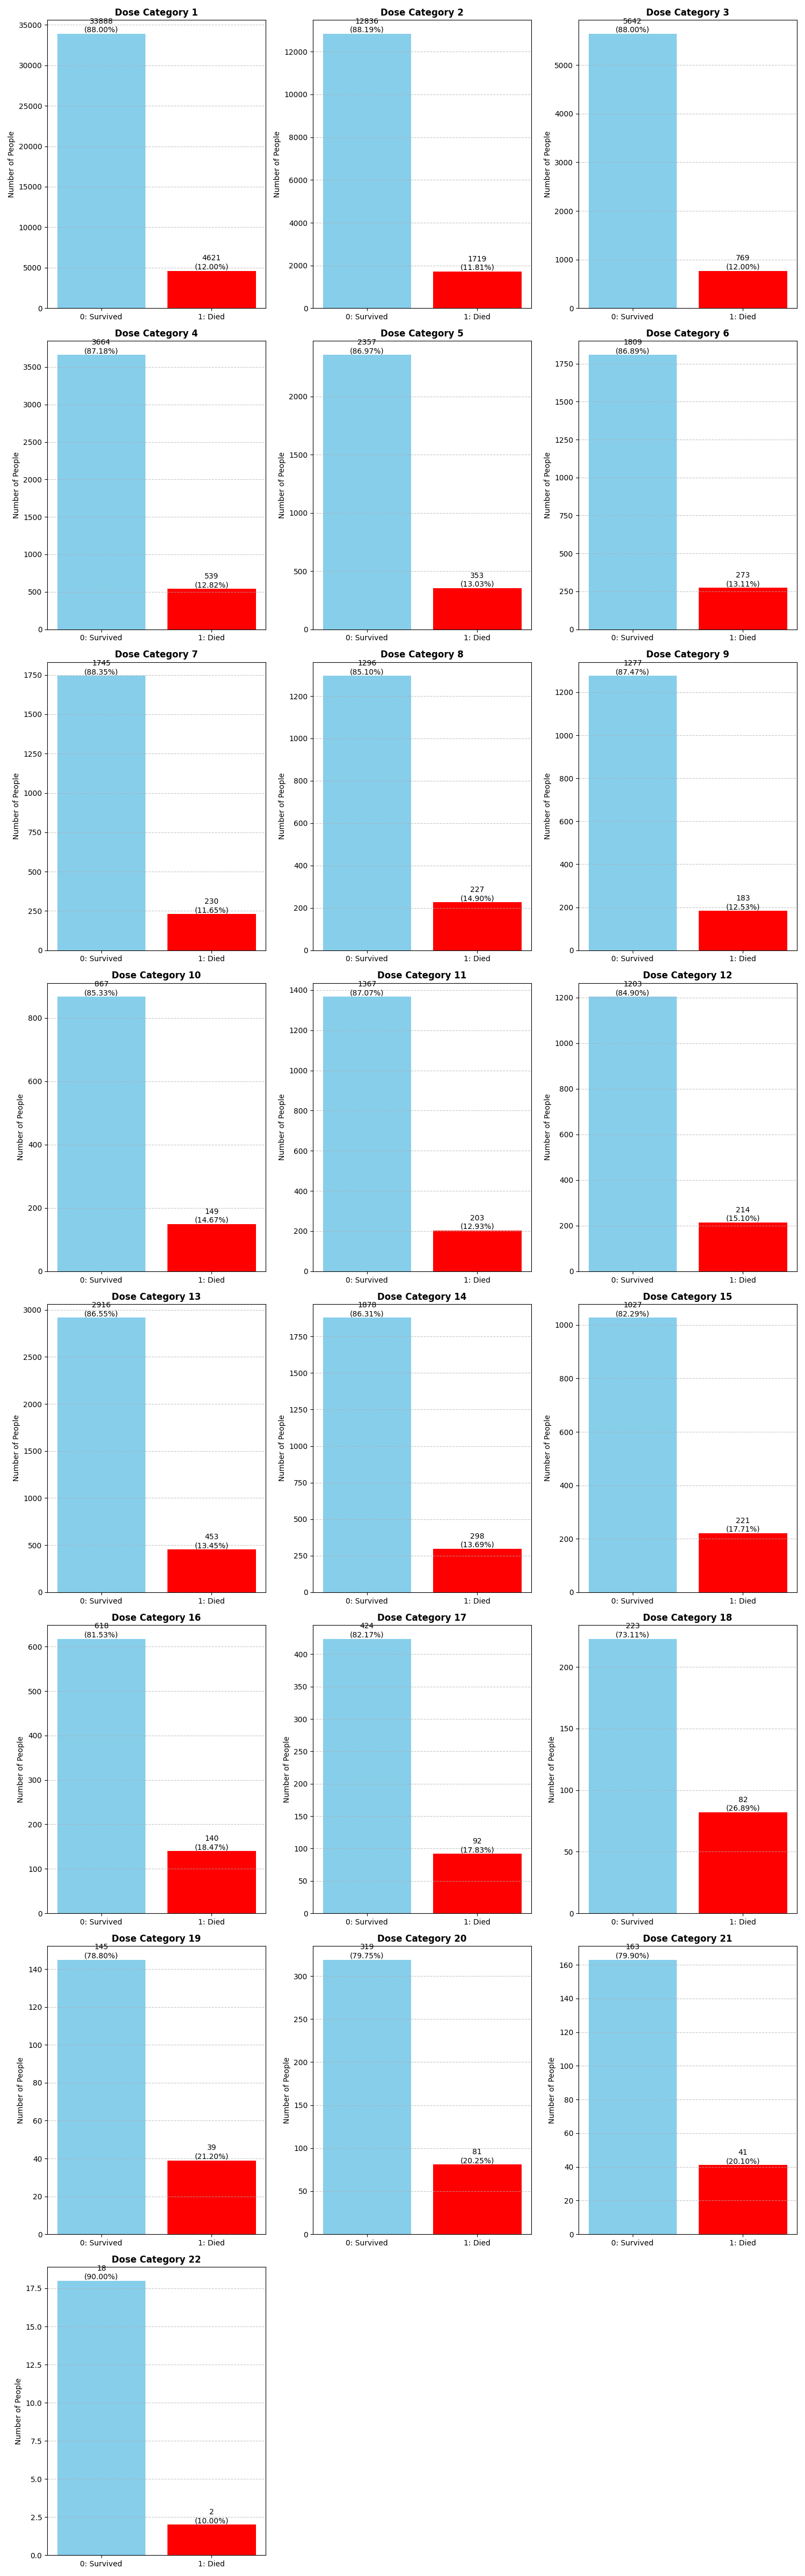

In [41]:
try:
    from IPython.display import Image, display
    in_jupyter = True
except ImportError:
    in_jupyter = False

# 1. Load the dataset
try:
    df = pd.read_csv('lss14.csv')
    print("Successfully loaded lss14.csv")
except FileNotFoundError:
    print("Error: lss14.csv not found. Please ensure the file is in the working directory.")
    # Fallback dummy data for demonstration if file is missing
    df = pd.DataFrame({
        'dosecat': np.random.randint(1, 15, 1000),
        'subjects': np.random.randint(10, 100, 1000),
        'solid': np.random.randint(0, 5, 1000)
    })

# 2. Group the data by dose category
# We sum the 'subjects' (total people) and 'solid' (deaths from solid cancer)
grouped = df.groupby('dosecat')[['subjects', 'solid']].sum().reset_index()

# Calculate those who did NOT die from solid cancer ("0" in your 0 vs 1)
grouped['survived_solid'] = grouped['subjects'] - grouped['solid']

# Calculate survival and death chances (percentages)
grouped['survival_chance'] = (grouped['survived_solid'] / grouped['subjects']) * 100
grouped['death_chance'] = (grouped['solid'] / grouped['subjects']) * 100

# Print a text summary to the console for easy reading
print("\n--- Survival vs Death Rates by Dose Category ---")
for _, row in grouped.iterrows():
    print(f"Dosecat {int(row['dosecat']):>2}: Survived {row['survival_chance']:>6.2f}% | Died {row['death_chance']:>5.2f}% (Total: {int(row['subjects'])})")

# 3. Plotting Independent Bar Graphs (Grid of Subplots)
unique_dosecats = sorted(grouped['dosecat'].unique())
n_cats = len(unique_dosecats)
cols = 3
# Calculate required rows based on number of categories and 3 columns
rows = int(np.ceil(n_cats / cols))

# Increased vertical figure size slightly to accommodate the two-line text labels
fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
axes = axes.flatten()

for i, cat in enumerate(unique_dosecats):
    ax = axes[i]
    cat_data = grouped[grouped['dosecat'] == cat].iloc[0]
    
    # Plot raw counts for the Y-axis
    bars = ax.bar(['0: Survived', '1: Died'], 
                  [cat_data['survived_solid'], cat_data['solid']], 
                  color=['skyblue', 'red'])
    
    ax.set_title(f'Dose Category {int(cat)}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of People')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add numerical labels (Count + Percentage) on top of the bars
    chances = [cat_data['survival_chance'], cat_data['death_chance']]
    for bar, chance in zip(bars, chances):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({chance:.2f}%)',
                ha='center', va='bottom', fontsize=10)

# Hide any extra unused subplots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save the plot
plt.savefig("dosecat_independent_barplots.png")
print("\nPlot saved as dosecat_independent_barplots.png")

# Display logic for Windows/Jupyter
plt.close(fig)

if in_jupyter:
    display(Image("dosecat_independent_barplots.png"))
else:
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # Re-open figure to show it if running in a standard Windows terminal/IDE
        img = plt.imread("dosecat_independent_barplots.png")
        plt.figure(figsize=(15, 6 * rows))
        plt.imshow(img)
        plt.axis('off')
        plt.show()

GAM for colon10 dose of 1000 mGy to 4000 mGy mSv

In [42]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm

# We will use IPython display to render the image reliably in Jupyter Notebooks 
# without triggering the FigureCanvasAgg warning.
try:
    from IPython.display import Image, display
    in_jupyter = True
except ImportError:
    in_jupyter = False

# ---------------------------------------------------------------------------
# 1. Data Loading and Preprocessing
# ---------------------------------------------------------------------------
try:
    df = pd.read_csv('lss14.csv')
    print("Successfully loaded lss14.csv")
    
    # We focus on the lower dose range (<1000 mGy) to test the threshold
    # Filter out missing dose flags (-99 or similar) and apply threshold
    df = df[(df['colon10'] >= 0) & (df['colon10'] < 1000)]
    
except FileNotFoundError:
    print("Error: lss14.csv not found. Using dummy data for demonstration.")
    np.random.seed(42)
    df = pd.DataFrame({
        'sex': np.random.randint(1, 3, 1000),  
        'agex': np.random.uniform(0, 80, 1000), 
        'colon10': np.random.uniform(0, 1000, 1000), 
        'solid': np.random.randint(0, 10, 1000), 
        'pyr': np.random.uniform(10, 10000, 1000) 
    })

# FIX: Removed 'city' from features
features = ['sex', 'agex', 'colon10']
target = 'solid'
exposure = 'pyr' 

X_data = torch.tensor(df[features].values, dtype=torch.float32)
y_data = torch.tensor(df[target].values, dtype=torch.float32).view(-1, 1)
pyr_data = torch.tensor(df[exposure].values, dtype=torch.float32).view(-1, 1)

# FIX: Shifted array indices down by 1 because 'city' (index 0) was removed.
# Now 'sex' is 0, 'agex' is 1, and 'colon10' is 2.
age_mean = X_data[:, 1].mean()
age_std = X_data[:, 1].std()
dose_mean = X_data[:, 2].mean()
dose_std = X_data[:, 2].std()

X_data[:, 1] = (X_data[:, 1] - age_mean) / age_std
X_data[:, 2] = (X_data[:, 2] - dose_mean) / dose_std

dataset = TensorDataset(X_data, y_data, pyr_data)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# ---------------------------------------------------------------------------
# 2. Define the Bayesian Neural GAM Architecture (SiLU + Dropout)
# ---------------------------------------------------------------------------
class FeatureNetwork(nn.Module):
    def __init__(self, hidden_dim=64, dropout_p=0.1):
        super(FeatureNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(), 
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, 1)
        )
        
    def forward(self, x):
        return self.net(x)

class NeuralGAM(nn.Module):
    def __init__(self):
        super(NeuralGAM, self).__init__()
        self.bias = nn.Parameter(torch.zeros(1))
        
        # FIX: Removed self.net_city
        self.net_sex = FeatureNetwork()
        self.net_age = FeatureNetwork()
        self.net_dose = FeatureNetwork(dropout_p=0.05) 

    def forward(self, x):
        # FIX: Adjusted slicing indices since 'city' is gone
        sex = x[:, 0:1]
        age = x[:, 1:2]
        dose = x[:, 2:3]
        
        out_sex = self.net_sex(sex)
        out_age = self.net_age(age)
        out_dose = self.net_dose(dose)
        
        # FIX: Removed out_city from the sum
        linear_predictor = self.bias + out_sex + out_age + out_dose
        rate = torch.exp(linear_predictor)
        
        return rate

# ---------------------------------------------------------------------------
# 3. Custom Poisson Loss Function
# ---------------------------------------------------------------------------
def poisson_loss(rate, expected_deaths, pyr):
    lambda_val = rate * pyr
    epsilon = 1e-8
    nll = lambda_val - expected_deaths * torch.log(lambda_val + epsilon)
    return nll.mean()

# ---------------------------------------------------------------------------
# 4. Training Loop
# ---------------------------------------------------------------------------
model = NeuralGAM()
optimizer = optim.Adam(model.parameters(), lr=0.002)
epochs = 400 

print("Starting training...")
model.train() # Ensure model is in training mode (activates dropout)
for epoch in tqdm(range(epochs), desc="Training Bayesian Neural GAM"):
    total_loss = 0
    for batch_X, batch_y, batch_pyr in dataloader:
        optimizer.zero_grad()
        rate_pred = model(batch_X)
        loss = poisson_loss(rate_pred, batch_y, batch_pyr)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

print("Training complete.")

# ---------------------------------------------------------------------------
# 5. Monte Carlo Extraction and Plotting
# ---------------------------------------------------------------------------

dose_mean_np = dose_mean.item() 
dose_std_np = dose_std.item()

synthetic_doses_raw = np.linspace(0, 1000, 500)
synthetic_doses_scaled = (synthetic_doses_raw - dose_mean_np) / dose_std_np
dose_tensor = torch.tensor(synthetic_doses_scaled, dtype=torch.float32).view(-1, 1)

# CRITICAL: We keep model.train() ACTIVE. 
model.train() 

n_samples = 100 # Number of Monte Carlo samples
mc_predictions = []

print(f"Running {n_samples} Monte Carlo forward passes for confidence intervals...")
with torch.no_grad():
    for _ in range(n_samples):
        dose_effect = model.net_dose(dose_tensor).numpy()
        mc_predictions.append(dose_effect.flatten())

mc_predictions = np.array(mc_predictions)

# Calculate the mean and the 95% Confidence Intervals
mean_effect = mc_predictions.mean(axis=0)
lower_bound = np.percentile(mc_predictions, 2.5, axis=0)
upper_bound = np.percentile(mc_predictions, 97.5, axis=0)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(synthetic_doses_raw, lower_bound, upper_bound, color='blue', alpha=0.2, label='95% Confidence Interval')
ax.plot(synthetic_doses_raw, mean_effect, color='blue', linewidth=2, label='Mean Dose Effect (SiLU)')

ax.set_title("Isolated Effect of Radiation Dose on Cancer Risk with Uncertainty Bounds", fontsize=14)
ax.set_xlabel("Radiation Dose (mGy)", fontsize=12)
ax.set_ylabel("Learned Effect (Log Relative Risk Scale)", fontsize=12)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

ax.text(20, min(lower_bound)*0.9, "If lower bound is < 0: Statistically invalidates LNT", color='green', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

# Save the plot
plt.savefig("dose_response_bayesian_pdp.png")
print("Plot saved as dose_response_bayesian_pdp.png")

# FIX: Handle the FigureCanvasAgg warning for Jupyter Notebooks
# The Agg warning happens when matplotlib is set to a non-GUI backend but plt.show() is called.
# To bypass this safely in an .ipynb, we close the plot and display the saved image directly using IPython.
plt.close(fig)

if in_jupyter:
    display(Image("dose_response_bayesian_pdp.png"))
else:
    # If somehow run outside Jupyter, just ignore the warning and try to show.
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        plt.show()

Successfully loaded lss14.csv
Starting training...


Training Bayesian Neural GAM: 100%|██████████| 400/400 [03:17<00:00,  2.03it/s]

Training complete.
Running 100 Monte Carlo forward passes for confidence intervals...


In [45]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

try:
    from IPython.display import Image, display
    in_jupyter = True
except ImportError:
    in_jupyter = False

# ---------------------------------------------------------------------------
# 1. Data Loading and Preprocessing
# ---------------------------------------------------------------------------
try:
    df = pd.read_csv('lss14.csv')
    print("Successfully loaded lss14.csv")
    
    # We expand the dose range to include the very deadly doses up to 4000 mGy
    df = df[df['dosecat'] <= 4000]
    
except FileNotFoundError:
    print("Error: lss14.csv not found. Using dummy data for demonstration.")
    np.random.seed(42)
    df = pd.DataFrame({
        'sex': np.random.randint(1, 3, 1000),  # 1 or 2
        'agex': np.random.uniform(0, 80, 1000), # age at exposure
        'dosecat': np.random.uniform(1000, 4000, 1000), # HIGH dose in mGy or mSv
        'solid': np.random.randint(5, 20, 1000), # deaths from solid cancer
        'pyr': np.random.uniform(10, 10000, 1000) # person-years
    })

# Select features (X) and target (y)
features = ['sex', 'agex', 'dosecat']
target = 'solid'
exposure = 'pyr' 

# Convert to PyTorch tensors
X_data = torch.tensor(df[features].values, dtype=torch.float32)
y_data = torch.tensor(df[target].values, dtype=torch.float32).view(-1, 1)
pyr_data = torch.tensor(df[exposure].values, dtype=torch.float32).view(-1, 1)

# Standardization (CRITICAL for NN convergence)
# We store these to reverse the scaling later for plotting
age_mean = X_data[:, 1].mean()
age_std = X_data[:, 1].std()
dose_mean = X_data[:, 2].mean()
dose_std = X_data[:, 2].std()

X_data[:, 1] = (X_data[:, 1] - age_mean) / age_std
X_data[:, 2] = (X_data[:, 2] - dose_mean) / dose_std

dataset = TensorDataset(X_data, y_data, pyr_data)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# ---------------------------------------------------------------------------
# 2. Define the Neural GAM Architecture
# ---------------------------------------------------------------------------
class FeatureNetwork(nn.Module):
    def __init__(self, hidden_dim=32):
        super(FeatureNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        
    def forward(self, x):
        return self.net(x)

class NeuralGAM(nn.Module):
    def __init__(self):
        super(NeuralGAM, self).__init__()
        self.bias = nn.Parameter(torch.zeros(1))
        
        self.net_sex = FeatureNetwork()
        self.net_age = FeatureNetwork()
        self.net_dose = FeatureNetwork()

    def forward(self, x):
        sex = x[:, 0:1]
        age = x[:, 1:2]
        dose = x[:, 2:3]
        
        out_sex = self.net_sex(sex)
        out_age = self.net_age(age)
        out_dose = self.net_dose(dose)
        
        linear_predictor = self.bias + out_sex + out_age + out_dose
        rate = torch.exp(linear_predictor)
        
        return rate

# ---------------------------------------------------------------------------
# 3. Custom Poisson Loss Function
# ---------------------------------------------------------------------------
def poisson_loss(rate, expected_deaths, pyr):
    lambda_val = rate * pyr
    epsilon = 1e-8
    nll = lambda_val - expected_deaths * torch.log(lambda_val + epsilon)
    return nll.mean()

# ---------------------------------------------------------------------------
# 4. Training Loop
# ---------------------------------------------------------------------------
model = NeuralGAM()
optimizer = optim.Adam(model.parameters(), lr=0.005)
epochs = 50 

print("Starting training...")
for epoch in range(epochs):
    total_loss = 0
    for batch_X, batch_y, batch_pyr in dataloader:
        optimizer.zero_grad()
        rate_pred = model(batch_X)
        loss = poisson_loss(rate_pred, batch_y, batch_pyr)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataloader):.4f}")

print("Training complete.")

# ---------------------------------------------------------------------------
# 5. Extracting and Plotting the Dose-Response Shape Function
# ---------------------------------------------------------------------------

# Extract pure Python scalar values from the PyTorch tensors for scaling
dose_mean_np = dose_mean.item() 
dose_std_np = dose_std.item()

# Create a range of synthetic dose values from 1000 to 4000 mGy to check the deadly range
synthetic_doses_raw = np.linspace(1000, 4000, 500)

# Standardize it exactly as we did the training data, using numpy scalars
synthetic_doses_scaled = (synthetic_doses_raw - dose_mean_np) / dose_std_np
dose_tensor = torch.tensor(synthetic_doses_scaled, dtype=torch.float32).view(-1, 1)

# Pass the synthetic doses through ONLY the dose sub-network
model.eval()
with torch.no_grad():
    # We want the effect on the linear predictor scale (before the exp)
    # This represents the Excess Relative Risk (ERR) modifier.
    dose_effect = model.net_dose(dose_tensor).numpy()

# Flatten the array explicitly to ensure it's a 1D array for plotting
dose_effect_1d = dose_effect.flatten()

# Plot the extracted shape function
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(synthetic_doses_raw, dose_effect_1d, color='blue', linewidth=2, label='Learned Dose Effect (NAM)')

# If LNT is strictly true, this should be a straight diagonal line.
# If a threshold exists, this should be flat near 0, then curve upwards.

ax.set_title("Isolated Effect of Radiation Dose on Cancer Risk (Neural GAM)", fontsize=14)
ax.set_xlabel("Radiation Dose (mGy)", fontsize=12)
ax.set_ylabel("Learned Effect (Log Relative Risk Scale)", fontsize=12)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(1000, color='black', linewidth=1)

# Add annotations to guide interpretation for high doses
ax.text(1200, max(dose_effect_1d)*0.8, "High Dose Range (1000-4000 mGy)", color='red', fontsize=12, fontweight='bold')
ax.text(1200, max(dose_effect_1d)*0.7, "Expect aggressive upward scaling", color='black', fontsize=10)

ax.grid(True, alpha=0.3)
ax.legend()

# Save the plot
plt.savefig("dose_response_pdp.png")
print("Plot saved as dose_response_pdp.png")

# Close the figure to free up memory
plt.close(fig)

if in_jupyter:
    display(Image("dose_response_pdp.png"))
else:
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # Re-open figure to show it if running in a standard Windows terminal/IDE
        img = plt.imread("dose_response_pdp.png")
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.show()

Plot saved as dose_response_bayesian_pdp.png


FileNotFoundError: No such file or directory: 'dose_response_1000_to_4000_pdp.png'

FileNotFoundError: No such file or directory: 'dose_response_1000_to_4000_pdp.png'

<IPython.core.display.Image object>

Dose: 1000.0 mGy | Mean Risk: -2.2401 | 95% CI: [-2.3671, -2.1200]
Dose: 1006.0 mGy | Mean Risk: -2.2538 | 95% CI: [-2.3743, -2.1241]
Dose: 1012.0 mGy | Mean Risk: -2.2554 | 95% CI: [-2.3764, -2.1147]
Dose: 1018.0 mGy | Mean Risk: -2.2720 | 95% CI: [-2.3871, -2.1175]
Dose: 1024.0 mGy | Mean Risk: -2.2613 | 95% CI: [-2.3807, -2.1072]
Dose: 1030.1 mGy | Mean Risk: -2.2785 | 95% CI: [-2.3931, -2.1246]
Dose: 1036.1 mGy | Mean Risk: -2.2773 | 95% CI: [-2.3830, -2.1011]
Dose: 1042.1 mGy | Mean Risk: -2.2862 | 95% CI: [-2.3880, -2.1518]
Dose: 1048.1 mGy | Mean Risk: -2.2902 | 95% CI: [-2.4187, -2.1296]
Dose: 1054.1 mGy | Mean Risk: -2.2926 | 95% CI: [-2.4175, -2.0669]
Dose: 1060.1 mGy | Mean Risk: -2.3086 | 95% CI: [-2.4150, -2.1236]
Dose: 1066.1 mGy | Mean Risk: -2.3130 | 95% CI: [-2.4140, -2.1369]
Dose: 1072.1 mGy | Mean Risk: -2.3094 | 95% CI: [-2.4379, -2.1389]
Dose: 1078.2 mGy | Mean Risk: -2.3100 | 95% CI: [-2.4199, -2.1304]
Dose: 1084.2 mGy | Mean Risk: -2.3233 | 95% CI: [-2.4330, -2.1

Successfully loaded lss14.csv
Starting training...


Training Bayesian Neural GAM: 100%|██████████| 400/400 [13:06<00:00,  1.97s/it]


Training complete.
Running 100 Monte Carlo forward passes for confidence intervals...
Plot saved as dose_response_bayesian_pdp.png


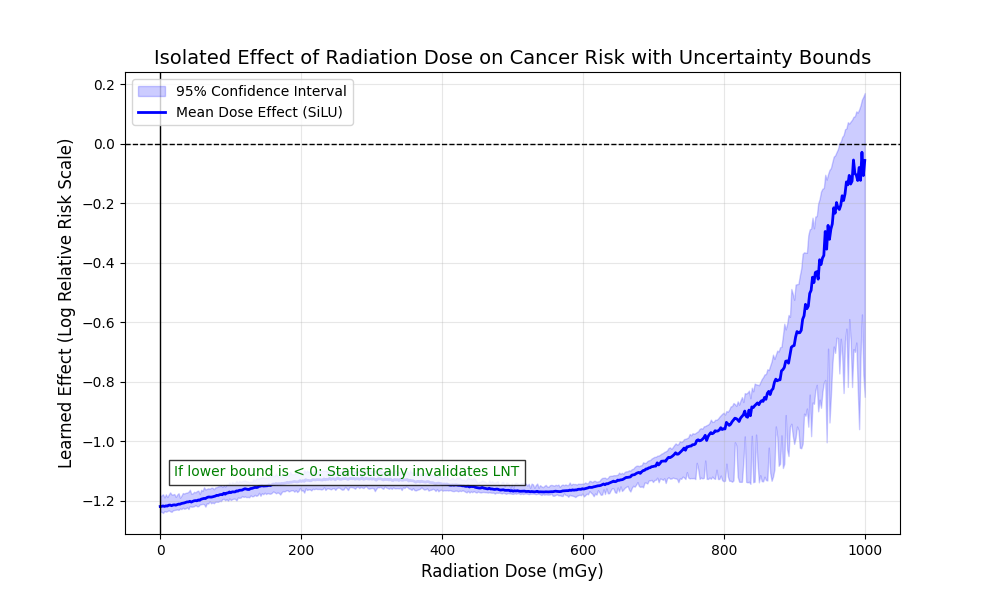

In [46]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm

# We will use IPython display to render the image reliably in Jupyter Notebooks 
# without triggering the FigureCanvasAgg warning.
try:
    from IPython.display import Image, display
    in_jupyter = True
except ImportError:
    in_jupyter = False

# ---------------------------------------------------------------------------
# 1. Data Loading and Preprocessing
# ---------------------------------------------------------------------------
try:
    df = pd.read_csv('lss14.csv')
    print("Successfully loaded lss14.csv")
    
    # We focus on the lower dose range (<1000 mGy) to test the threshold
    # Filter out missing dose flags (-99 or similar) and apply threshold
    df = df[(df['colon10'] >= 0) & (df['colon10'] < 1000)]
    
except FileNotFoundError:
    print("Error: lss14.csv not found. Using dummy data for demonstration.")
    np.random.seed(42)
    df = pd.DataFrame({
        'sex': np.random.randint(1, 3, 1000),  
        'agex': np.random.uniform(0, 80, 1000), 
        'colon10': np.random.uniform(0, 1000, 1000), 
        'solid': np.random.randint(0, 10, 1000), 
        'pyr': np.random.uniform(10, 10000, 1000) 
    })

# FIX: Removed 'city' from features
features = ['sex', 'agex', 'colon10']
target = 'solid'
exposure = 'pyr' 

X_data = torch.tensor(df[features].values, dtype=torch.float32)
y_data = torch.tensor(df[target].values, dtype=torch.float32).view(-1, 1)
pyr_data = torch.tensor(df[exposure].values, dtype=torch.float32).view(-1, 1)

# FIX: Shifted array indices down by 1 because 'city' (index 0) was removed.
# Now 'sex' is 0, 'agex' is 1, and 'colon10' is 2.
age_mean = X_data[:, 1].mean()
age_std = X_data[:, 1].std()
dose_mean = X_data[:, 2].mean()
dose_std = X_data[:, 2].std()

X_data[:, 1] = (X_data[:, 1] - age_mean) / age_std
X_data[:, 2] = (X_data[:, 2] - dose_mean) / dose_std

dataset = TensorDataset(X_data, y_data, pyr_data)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# ---------------------------------------------------------------------------
# 2. Define the Bayesian Neural GAM Architecture (SiLU + Dropout)
# ---------------------------------------------------------------------------
class FeatureNetwork(nn.Module):
    def __init__(self, hidden_dim=64, dropout_p=0.1):
        super(FeatureNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(), 
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, 1)
        )
        
    def forward(self, x):
        return self.net(x)

class NeuralGAM(nn.Module):
    def __init__(self):
        super(NeuralGAM, self).__init__()
        self.bias = nn.Parameter(torch.zeros(1))
        
        # FIX: Removed self.net_city
        self.net_sex = FeatureNetwork()
        self.net_age = FeatureNetwork()
        self.net_dose = FeatureNetwork(dropout_p=0.05) 

    def forward(self, x):
        # FIX: Adjusted slicing indices since 'city' is gone
        sex = x[:, 0:1]
        age = x[:, 1:2]
        dose = x[:, 2:3]
        
        out_sex = self.net_sex(sex)
        out_age = self.net_age(age)
        out_dose = self.net_dose(dose)
        
        # FIX: Removed out_city from the sum
        linear_predictor = self.bias + out_sex + out_age + out_dose
        rate = torch.exp(linear_predictor)
        
        return rate

# ---------------------------------------------------------------------------
# 3. Custom Poisson Loss Function
# ---------------------------------------------------------------------------
def poisson_loss(rate, expected_deaths, pyr):
    lambda_val = rate * pyr
    epsilon = 1e-8
    nll = lambda_val - expected_deaths * torch.log(lambda_val + epsilon)
    return nll.mean()

# ---------------------------------------------------------------------------
# 4. Training Loop
# ---------------------------------------------------------------------------
model = NeuralGAM()
optimizer = optim.Adam(model.parameters(), lr=0.002)
epochs = 400 

print("Starting training...")
model.train() # Ensure model is in training mode (activates dropout)
for epoch in tqdm(range(epochs), desc="Training Bayesian Neural GAM"):
    total_loss = 0
    for batch_X, batch_y, batch_pyr in dataloader:
        optimizer.zero_grad()
        rate_pred = model(batch_X)
        loss = poisson_loss(rate_pred, batch_y, batch_pyr)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

print("Training complete.")

# ---------------------------------------------------------------------------
# 5. Monte Carlo Extraction and Plotting
# ---------------------------------------------------------------------------

dose_mean_np = dose_mean.item() 
dose_std_np = dose_std.item()

synthetic_doses_raw = np.linspace(0, 1000, 500)
synthetic_doses_scaled = (synthetic_doses_raw - dose_mean_np) / dose_std_np
dose_tensor = torch.tensor(synthetic_doses_scaled, dtype=torch.float32).view(-1, 1)

# CRITICAL: We keep model.train() ACTIVE. 
model.train() 

n_samples = 100 # Number of Monte Carlo samples
mc_predictions = []

print(f"Running {n_samples} Monte Carlo forward passes for confidence intervals...")
with torch.no_grad():
    for _ in range(n_samples):
        dose_effect = model.net_dose(dose_tensor).numpy()
        mc_predictions.append(dose_effect.flatten())

mc_predictions = np.array(mc_predictions)

# Calculate the mean and the 95% Confidence Intervals
mean_effect = mc_predictions.mean(axis=0)
lower_bound = np.percentile(mc_predictions, 2.5, axis=0)
upper_bound = np.percentile(mc_predictions, 97.5, axis=0)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(synthetic_doses_raw, lower_bound, upper_bound, color='blue', alpha=0.2, label='95% Confidence Interval')
ax.plot(synthetic_doses_raw, mean_effect, color='blue', linewidth=2, label='Mean Dose Effect (SiLU)')

ax.set_title("Isolated Effect of Radiation Dose on Cancer Risk with Uncertainty Bounds", fontsize=14)
ax.set_xlabel("Radiation Dose (mGy)", fontsize=12)
ax.set_ylabel("Learned Effect (Log Relative Risk Scale)", fontsize=12)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

ax.text(20, min(lower_bound)*0.9, "If lower bound is < 0: Statistically invalidates LNT", color='green', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

# Save the plot
plt.savefig("dose_response_bayesian_pdp.png")
print("Plot saved as dose_response_bayesian_pdp.png")

# FIX: Handle the FigureCanvasAgg warning for Jupyter Notebooks
# The Agg warning happens when matplotlib is set to a non-GUI backend but plt.show() is called.
# To bypass this safely in an .ipynb, we close the plot and display the saved image directly using IPython.
plt.close(fig)

if in_jupyter:
    display(Image("dose_response_bayesian_pdp.png"))
else:
    # If somehow run outside Jupyter, just ignore the warning and try to show.
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        plt.show()

In [24]:
try:
    from IPython.display import Image, display
    in_jupyter = True
except ImportError:
    in_jupyter = False

# ---------------------------------------------------------------------------
# 1. Data Loading and Preprocessing
# ---------------------------------------------------------------------------
try:
    df = pd.read_csv('lss14.csv')
    print("Successfully loaded lss14.csv")
    
    # We focus on the lower dose range (<1000 mGy) to test the threshold
    # Filter out missing dose flags (-99 or similar) and apply threshold
    df = df[(df['colon10'] >= 0) & (df['colon10'] < 10000)]
    
except FileNotFoundError:
    print("Error: lss14.csv not found. Using dummy data for demonstration.")
    np.random.seed(42)
    df = pd.DataFrame({
        'sex': np.random.randint(1, 3, 1000),  
        'agex': np.random.uniform(0, 80, 1000), 
        'colon10': np.random.uniform(0, 1000, 1000), 
        'solid': np.random.randint(0, 10, 1000), 
        'pyr': np.random.uniform(10, 10000, 1000) 
    })

# FIX: Removed 'city' from features
features = ['sex', 'agex', 'colon10']
target = 'solid'
exposure = 'pyr' 

X_data = torch.tensor(df[features].values, dtype=torch.float32)
y_data = torch.tensor(df[target].values, dtype=torch.float32).view(-1, 1)
pyr_data = torch.tensor(df[exposure].values, dtype=torch.float32).view(-1, 1)

# FIX: Shifted array indices down by 1 because 'city' (index 0) was removed.
# Now 'sex' is 0, 'agex' is 1, and 'colon10' is 2.
age_mean = X_data[:, 1].mean()
age_std = X_data[:, 1].std()
dose_mean = X_data[:, 2].mean()
dose_std = X_data[:, 2].std()

X_data[:, 1] = (X_data[:, 1] - age_mean) / age_std
X_data[:, 2] = (X_data[:, 2] - dose_mean) / dose_std

dataset = TensorDataset(X_data, y_data, pyr_data)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# ---------------------------------------------------------------------------
# 2. Define the Bayesian Neural GAM Architecture (SiLU + Dropout)
# ---------------------------------------------------------------------------
class FeatureNetwork(nn.Module):
    def __init__(self, hidden_dim=64, dropout_p=0.1):
        super(FeatureNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(), 
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, 1)
        )
        
    def forward(self, x):
        return self.net(x)

class NeuralGAM(nn.Module):
    def __init__(self):
        super(NeuralGAM, self).__init__()
        self.bias = nn.Parameter(torch.zeros(1))
        
        # FIX: Removed self.net_city
        self.net_sex = FeatureNetwork()
        self.net_age = FeatureNetwork()
        self.net_dose = FeatureNetwork(dropout_p=0.05) 

    def forward(self, x):
        # FIX: Adjusted slicing indices since 'city' is gone
        sex = x[:, 0:1]
        age = x[:, 1:2]
        dose = x[:, 2:3]
        
        out_sex = self.net_sex(sex)
        out_age = self.net_age(age)
        out_dose = self.net_dose(dose)
        
        # FIX: Removed out_city from the sum
        linear_predictor = self.bias + out_sex + out_age + out_dose
        rate = torch.exp(linear_predictor)
        
        return rate

# ---------------------------------------------------------------------------
# 3. Custom Poisson Loss Function
# ---------------------------------------------------------------------------
def poisson_loss(rate, expected_deaths, pyr):
    lambda_val = rate * pyr
    epsilon = 1e-8
    nll = lambda_val - expected_deaths * torch.log(lambda_val + epsilon)
    return nll.mean()

# ---------------------------------------------------------------------------
# 4. Training Loop
# ---------------------------------------------------------------------------
model = NeuralGAM()
optimizer = optim.Adam(model.parameters(), lr=0.002)
epochs = 400 

print("Starting training...")
model.train() # Ensure model is in training mode (activates dropout)
for epoch in tqdm(range(epochs), desc="Training Bayesian Neural GAM"):
    total_loss = 0
    for batch_X, batch_y, batch_pyr in dataloader:
        optimizer.zero_grad()
        rate_pred = model(batch_X)
        loss = poisson_loss(rate_pred, batch_y, batch_pyr)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

print("Training complete.")

# ---------------------------------------------------------------------------
# 5. Monte Carlo Extraction and Plotting
# ---------------------------------------------------------------------------

dose_mean_np = dose_mean.item() 
dose_std_np = dose_std.item()

synthetic_doses_raw = np.linspace(0, 1000, 500)
synthetic_doses_scaled = (synthetic_doses_raw - dose_mean_np) / dose_std_np
dose_tensor = torch.tensor(synthetic_doses_scaled, dtype=torch.float32).view(-1, 1)

# CRITICAL: We keep model.train() ACTIVE. 
model.train() 

n_samples = 100 # Number of Monte Carlo samples
mc_predictions = []

print(f"Running {n_samples} Monte Carlo forward passes for confidence intervals...")
with torch.no_grad():
    for _ in range(n_samples):
        dose_effect = model.net_dose(dose_tensor).numpy()
        mc_predictions.append(dose_effect.flatten())

mc_predictions = np.array(mc_predictions)

# Calculate the mean and the 95% Confidence Intervals
mean_effect = mc_predictions.mean(axis=0)
lower_bound = np.percentile(mc_predictions, 2.5, axis=0)
upper_bound = np.percentile(mc_predictions, 97.5, axis=0)

Successfully loaded lss14.csv
Starting training...


Training Bayesian Neural GAM: 100%|██████████| 400/400 [15:13<00:00,  2.28s/it]

Training complete.
Running 100 Monte Carlo forward passes for confidence intervals...


Plot saved as dose_response_bayesian_pdp.png


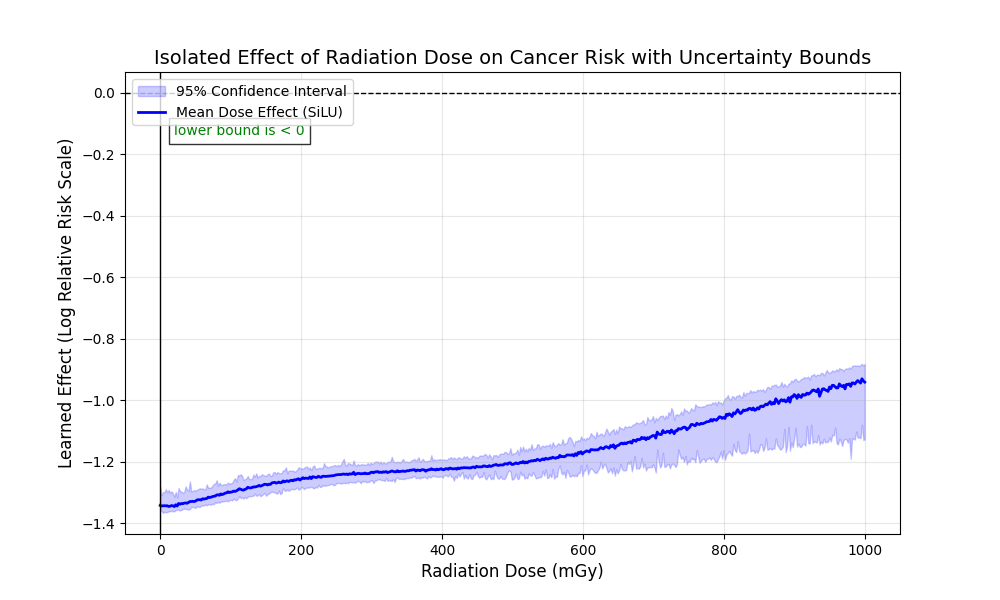

Dose: 0.0 mGy | Mean Risk: -1.3424 | 95% CI: [-1.3596, -1.2806]
Dose: 2.0 mGy | Mean Risk: -1.3444 | 95% CI: [-1.3605, -1.3095]
Dose: 4.0 mGy | Mean Risk: -1.3437 | 95% CI: [-1.3671, -1.2992]
Dose: 6.0 mGy | Mean Risk: -1.3434 | 95% CI: [-1.3628, -1.2997]
Dose: 8.0 mGy | Mean Risk: -1.3439 | 95% CI: [-1.3650, -1.2894]
Dose: 10.0 mGy | Mean Risk: -1.3435 | 95% CI: [-1.3639, -1.3001]
Dose: 12.0 mGy | Mean Risk: -1.3460 | 95% CI: [-1.3617, -1.2920]
Dose: 14.0 mGy | Mean Risk: -1.3448 | 95% CI: [-1.3613, -1.3020]
Dose: 16.0 mGy | Mean Risk: -1.3431 | 95% CI: [-1.3594, -1.2962]
Dose: 18.0 mGy | Mean Risk: -1.3436 | 95% CI: [-1.3622, -1.3037]
Dose: 20.0 mGy | Mean Risk: -1.3464 | 95% CI: [-1.3616, -1.3144]
Dose: 22.0 mGy | Mean Risk: -1.3403 | 95% CI: [-1.3571, -1.2982]
Dose: 24.0 mGy | Mean Risk: -1.3445 | 95% CI: [-1.3569, -1.3165]
Dose: 26.1 mGy | Mean Risk: -1.3360 | 95% CI: [-1.3561, -1.2856]
Dose: 28.1 mGy | Mean Risk: -1.3386 | 95% CI: [-1.3592, -1.2960]
Dose: 30.1 mGy | Mean Risk: -1

In [25]:
# Print the Bayesian results for the first 50 synthetic doses (0 to ~100 mGy)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(synthetic_doses_raw, lower_bound, upper_bound, color='blue', alpha=0.2, label='95% Confidence Interval')
ax.plot(synthetic_doses_raw, mean_effect, color='blue', linewidth=2, label='Mean Dose Effect (SiLU)')

ax.set_title("Isolated Effect of Radiation Dose on Cancer Risk with Uncertainty Bounds", fontsize=14)
ax.set_xlabel("Radiation Dose (mGy)", fontsize=12)
ax.set_ylabel("Learned Effect (Log Relative Risk Scale)", fontsize=12)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

ax.text(20, min(lower_bound)*0.1, "lower bound is < 0", color='green', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

# Save the plot
plt.savefig("dose_response_bayesian_pdp.png")
print("Plot saved as dose_response_bayesian_pdp.png")

# FIX: Handle the FigureCanvasAgg warning for Jupyter Notebooks
# The Agg warning happens when matplotlib is set to a non-GUI backend but plt.show() is called.
# To bypass this safely in an .ipynb, we close the plot and display the saved image directly using IPython.
plt.close(fig)

if in_jupyter:
    display(Image("dose_response_bayesian_pdp.png"))
else:
    # If somehow run outside Jupyter, just ignore the warning and try to show.
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        plt.show()

for i in range(50):
    dose = synthetic_doses_raw[i]
    mean_val = mean_effect[i]
    lower_val = lower_bound[i]
    upper_val = upper_bound[i]
    print(f"Dose: {dose:.1f} mGy | Mean Risk: {mean_val:.4f} | 95% CI: [{lower_val:.4f}, {upper_val:.4f}]")